In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/Daily Household Transactions.csv")
df.head()


,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR


In [ ]:
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2461 entries, 0 to 2460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2461 non-null   object 
 1   Mode            2461 non-null   object 
 2   Category        2461 non-null   object 
 3   Subcategory     1826 non-null   object 
 4   Note            1940 non-null   object 
 5   Amount          2461 non-null   float64
 6   Income/Expense  2461 non-null   object 
 7   Currency        2461 non-null   object 
dtypes: float64(1), object(7)
memory usage: 153.9+ KB


,Amount
count,2461.000000
mean,2751.145380
std,12519.615804
min,2.000000
25%,35.000000
50%,100.000000
75%,799.000000
max,250000.000000


In [ ]:
df['Subcategory'].fillna('Unknown', inplace=True)
df['Note'].fillna('Not Specified', inplace=True)


/tmp/ipython-input-2743467823.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Subcategory'].fillna('Unknown', inplace=True)
/tmp/ipython-input-2743467823.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)

In [ ]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.day_name()


In [ ]:
df['Expense_Flag'] = df['Income/Expense'].apply(lambda x: 1 if x=='Expense' else 0)


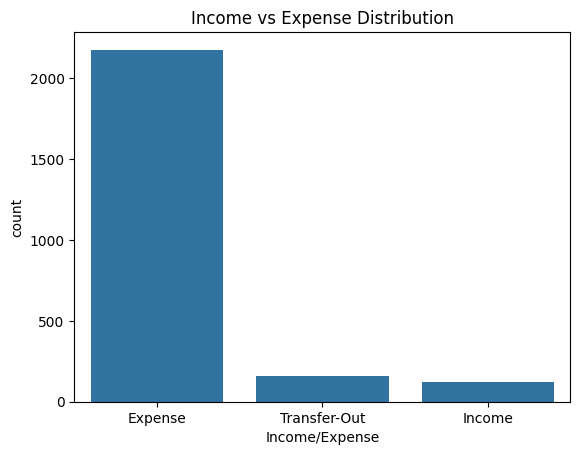

In [ ]:
sns.countplot(data=df, x='Income/Expense')
plt.title("Income vs Expense Distribution")
plt.show()


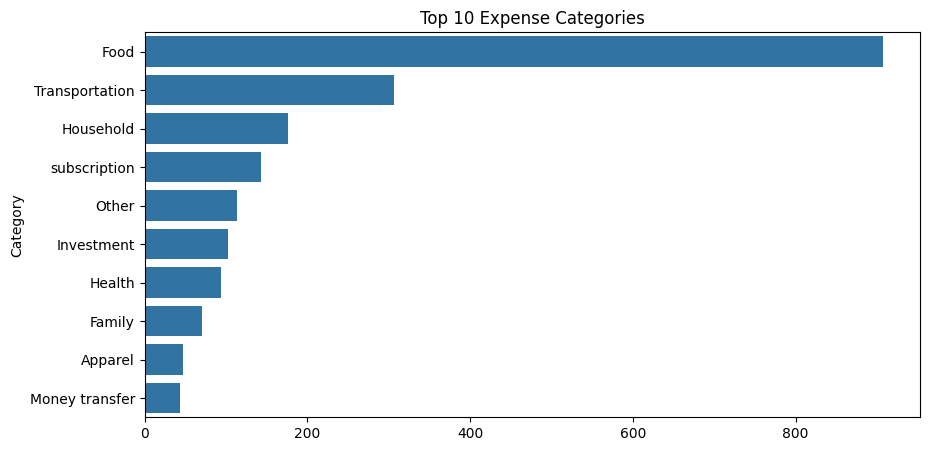

In [ ]:
top_cat = df[df['Income/Expense']=="Expense"]['Category'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_cat.values, y=top_cat.index)
plt.title("Top 10 Expense Categories")
plt.show()


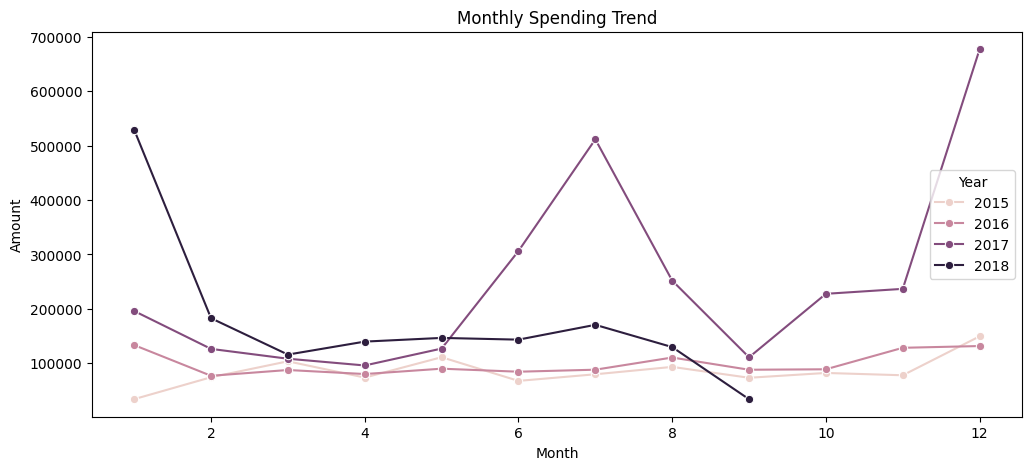

In [ ]:
monthly = df.groupby(['Year','Month'])['Amount'].sum().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly, x='Month', y='Amount', hue='Year', marker='o')
plt.title("Monthly Spending Trend")
plt.show()


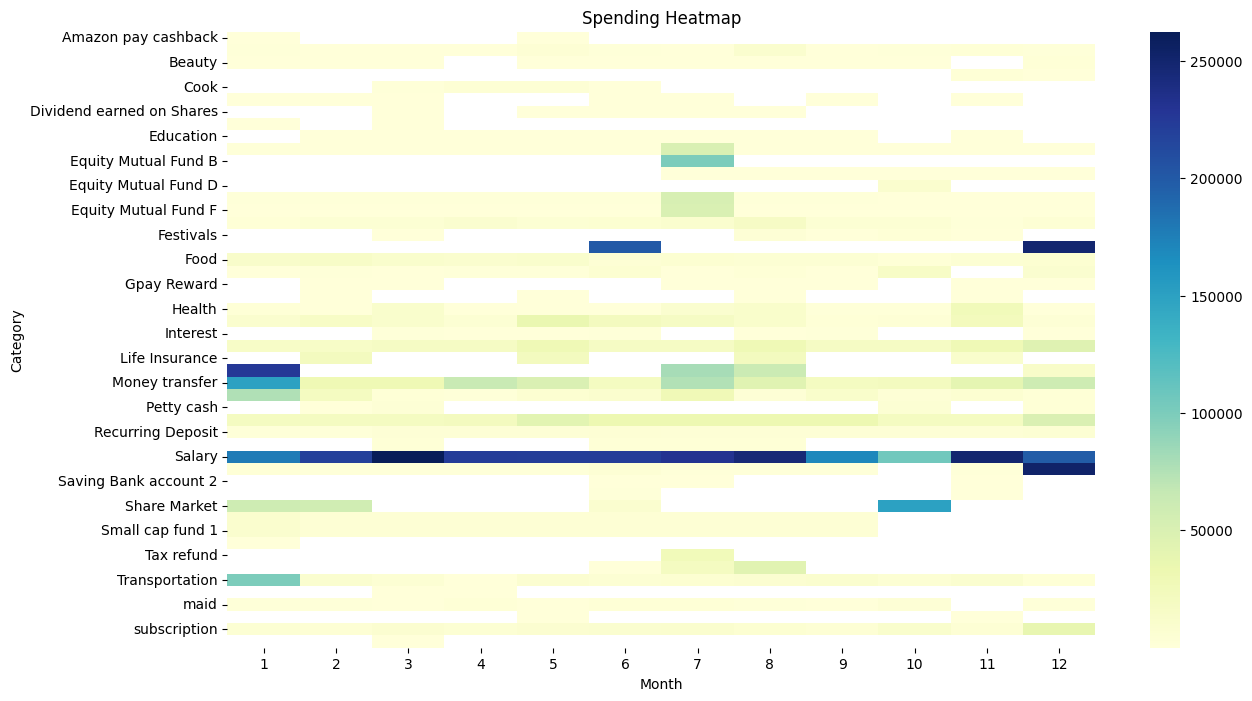

In [ ]:
pivot = df.pivot_table(values='Amount', index='Category', columns='Month', aggfunc='sum')
plt.figure(figsize=(14,8))
sns.heatmap(pivot, cmap='YlGnBu')
plt.title("Spending Heatmap")
plt.show()


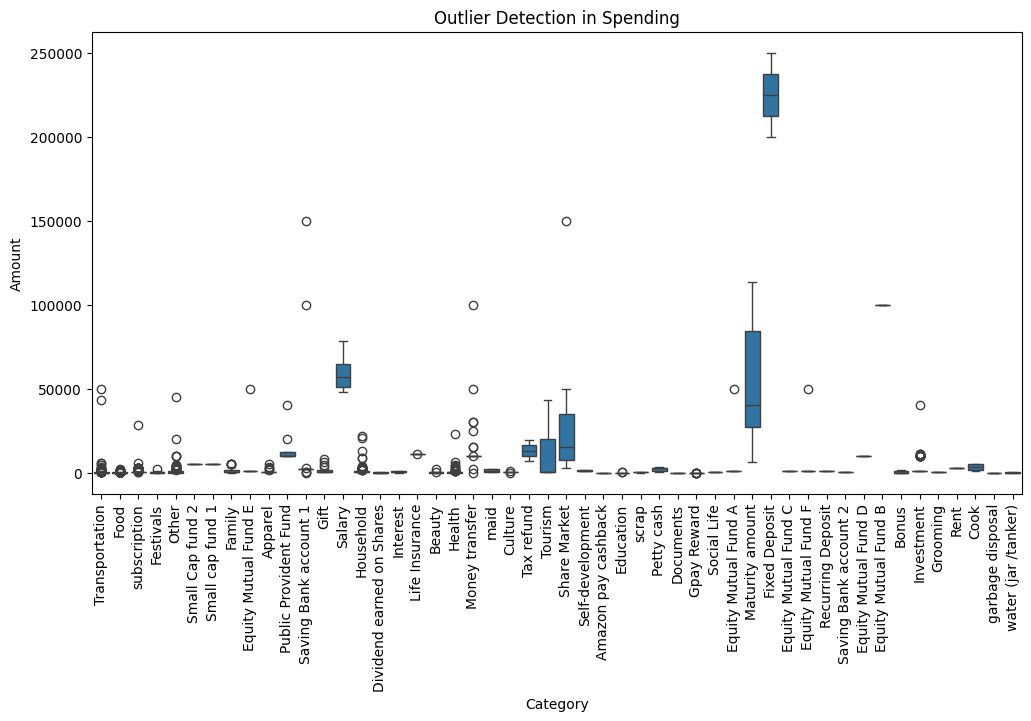

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Category', y='Amount', data=df)
plt.xticks(rotation=90)
plt.title("Outlier Detection in Spending")
plt.show()


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_data = df[['Amount']]
scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_data)

kmeans = KMeans(n_clusters=3, random_state=42)
df['Spending_Cluster'] = kmeans.fit_predict(scaled)


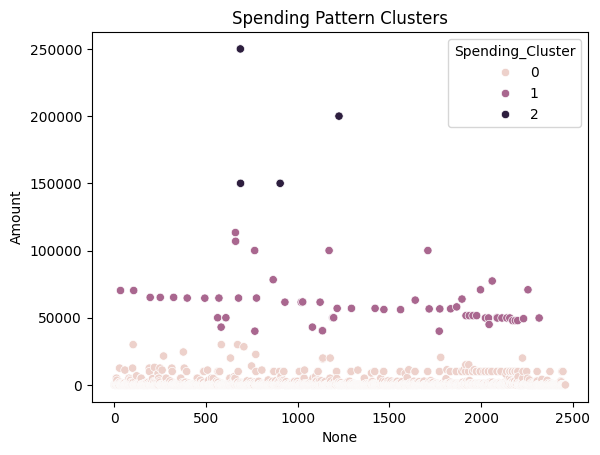

In [ ]:
sns.scatterplot(x=df.index, y='Amount', hue='Spending_Cluster', data=df)
plt.title("Spending Pattern Clusters")
plt.show()


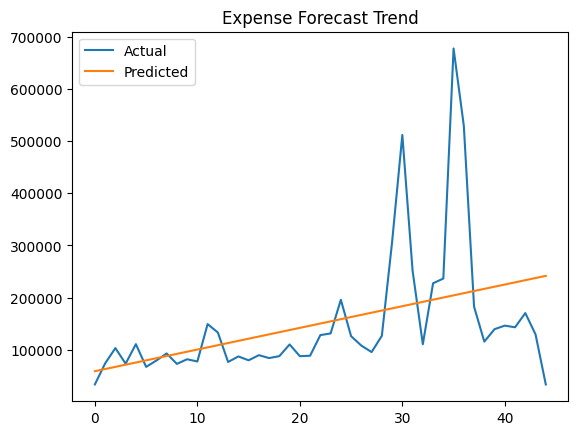

In [ ]:
monthly_sum = df.groupby(['Year','Month'])['Amount'].sum().reset_index()
monthly_sum['Index'] = range(len(monthly_sum))

from sklearn.linear_model import LinearRegression

X = monthly_sum[['Index']]
y = monthly_sum['Amount']

model = LinearRegression()
model.fit(X, y)

monthly_sum['Prediction'] = model.predict(X)

plt.plot(monthly_sum['Index'], monthly_sum['Amount'], label='Actual')
plt.plot(monthly_sum['Index'], monthly_sum['Prediction'], label='Predicted')
plt.legend()
plt.title("Expense Forecast Trend")
plt.show()


In [ ]:
df['Saving_Score'] = 100 - (df['Amount'] / df['Amount'].max()) * 100


In [ ]:
monthly_avg = df.groupby(['Year','Month'])['Amount'].mean()
recommended_budget = monthly_avg.tail(3).mean()
print("Recommended Monthly Budget:", recommended_budget)


Recommended Monthly Budget: 1607.6521656434334


In [ ]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

df['Anomaly'] = ((df['Amount'] < (Q1 - 1.5*IQR)) |
                 (df['Amount'] > (Q3 + 1.5*IQR)))


In [ ]:
df[['Amount', 'Anomaly']].head()


,Amount,Anomaly
0,30.0,False
1,60.0,False
2,199.0,False
3,19.0,False
4,251.0,False


In [ ]:
df['Anomaly'].value_counts()


,count
Anomaly,
False,2146
True,315


In [ ]:
df[df['Anomaly'] == True]


,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency,Month,Year,Day,Weekday,Expense_Flag,Spending_Cluster,Saving_Score,Anomaly,DayType
10,2018-09-13,Saving Bank account 1,Small Cap fund 2,Unknown,Not Specified,5000.0,Transfer-Out,INR,9,2018,13,Thursday,0,0,98.0000,True,Weekday
11,2018-09-13,Saving Bank account 1,Small cap fund 1,Unknown,Not Specified,5000.0,Transfer-Out,INR,9,2018,13,Thursday,0,0,98.0000,True,Weekday
14,2018-09-11,Saving Bank account 1,Other,Unknown,From Family,3500.0,Income,INR,9,2018,11,Tuesday,0,0,98.6000,True,Weekday
27,2018-09-03,Cash,Family,Pocket money,Not Specified,2000.0,Expense,INR,9,2018,3,Monday,1,0,99.2000,True,Weekday
28,2018-09-01,Saving Bank account 1,Public Provident Fund,Unknown,Not Specified,12500.0,Transfer-Out,INR,9,2018,1,Saturday,0,0,95.0000,True,Weekend
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2376,2015-02-02,Saving Bank account 1,Other,Unknown,Permanent Residence money transfer,10000.0,Expense,INR,2,2015,2,Monday,1,0,96.0000,True,Weekday
2435,2015-01-05,Cash,Other,Unknown,rent,2833.0,Expense,INR,1,2015,5,Monday,1,0,98.8668,True,Weekday
2438,2015-01-05,Cash,Other,Unknown,cook,2250.0,Expense,INR,1,2015,5,Monday,1,0,99.1000,True,Weekday
2442,2015-01-04,Saving Bank account 1,Other,Unknown,Public Provident Fund,10000.0,Expense,INR,1,2015,4,Sunday,1,0,96.0000,True,Weekend


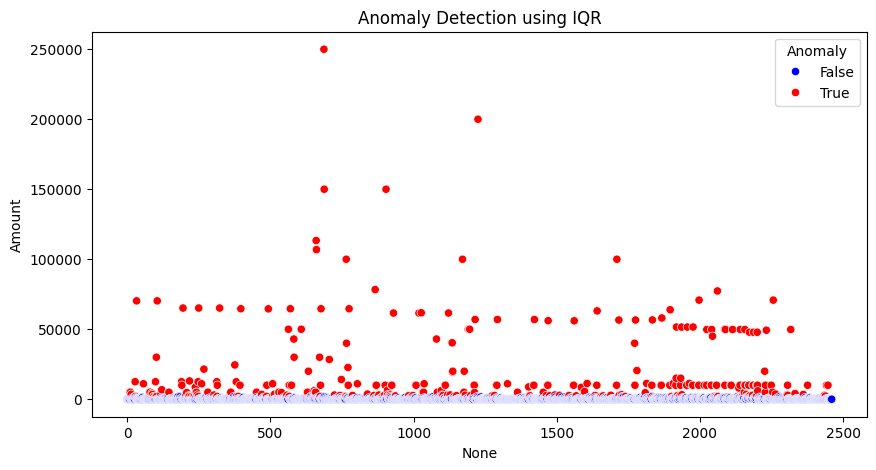

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.scatterplot(x=df.index, y=df['Amount'], hue=df['Anomaly'], palette=['blue','red'])
plt.title("Anomaly Detection using IQR")
plt.show()
